In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
import os
img_dir = ("/kaggle/input/datasets/jangedoo/utkface-new/UTKFace")
files = os.listdir(img_dir)

print(files[:5])

['26_0_2_20170104023102422.jpg.chip.jpg', '22_1_1_20170112233644761.jpg.chip.jpg', '21_1_3_20170105003215901.jpg.chip.jpg', '28_0_0_20170117180555824.jpg.chip.jpg', '17_1_4_20170103222931966.jpg.chip.jpg']


In [27]:
from PIL import Image
img_path = os.path.join(img_dir,files[22])
img = Image.open(img_path)
print(img)
print(img.size)

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=200x200 at 0x7B024D5EBBB0>
(200, 200)


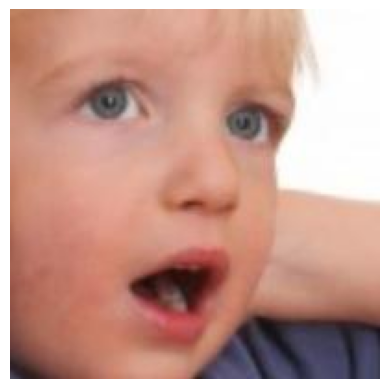

In [28]:
plt.imshow(img)
plt.axis("off")
plt.show()

In [43]:
import torch
import torch.nn as nn

class AgeCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3,16,3)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16,32,3)
        self.fc = nn.Linear(32*48*48,1)

    def forward(self,x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = torch.flatten(x,1)
        x = self.fc(x)

        return x

        

In [40]:
# model = AgeCNN()
# x = torch.randn(1, 3, 200, 200)
# output = model(x)
# print(output.shape)


torch.Size([1, 32, 48, 48])


In [ ]:
#  as my torch size is 1,32,48,48 means 1 batch , 32 features 48 , 48 spatial dimensions so my linear layer should contain (32*48*48*1) 1 refers to output.

In [44]:
model = AgeCNN()
x = torch.randn(1, 3, 200, 200)
output = model(x)
print(output.shape)


torch.Size([1, 1])


In [45]:
#  first 1 is batch size and second 1 is output as it is regression model thus output should be 1